# Mental Health Classification Model Building
This notebook converts the existing script into a more visual and structured ML workflow.

## Setup and Imports
Install and import required libraries for data processing, visualization, model training, and evaluation.

In [2]:
!python3 -m pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm nltk joblib

In [3]:


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import joblib

nltk.download('stopwords')
nltk.download('wordnet')
sns.set(style="whitegrid")
print("Environment and libraries are ready.")


Environment and libraries are ready.


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tht_developers/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tht_developers/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Load and Inspect Dataset
Load the dataset and inspect the shape, columns, sample records, and class distribution.

In [5]:
#DATA_PATH = os.path.join('app', 'db', 'Combined Data.csv')
df = pd.read_csv('/Users/tht_developers/Vscode-Asif/capstone_project/Backend/app/db/Combined Data.csv')
print("Dataset shape:", df.shape)
print(df.columns.tolist())
print(df.head(5))
print("Missing values by column:")
print(df.isnull().sum())
print("Class distribution:")
print(df["status"].value_counts(normalize=True).round(3))


Dataset shape: (53043, 3)
['Unnamed: 0', 'statement', 'status']
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
Missing values by column:
Unnamed: 0      0
statement     362
status          0
dtype: int64
Class distribution:
status
Normal                  0.308
Depression              0.290
Suicidal                0.201
Anxiety                 0.073
Bipolar                 0.054
Stress                  0.050
Personality disorder    0.023
Name: proportion, dtype: float64


## Exploratory Data Analysis
Visualize class balance, text length distribution, and sample text examples.

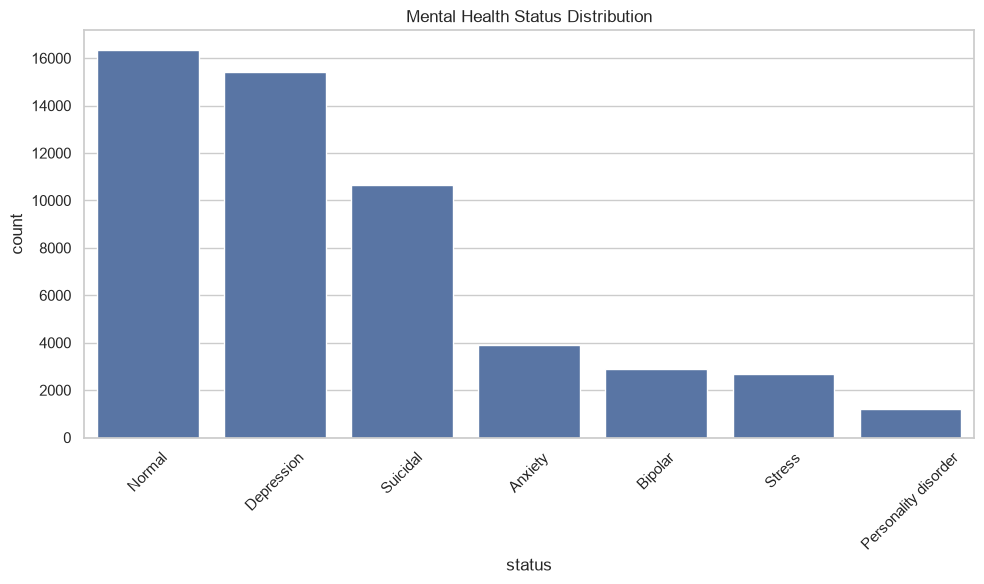

TypeError: object of type 'float' has no len()

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="status", order=df["status"].value_counts().index)
plt.title("Mental Health Status Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

if 'statement' in df.columns:
    df["text_length"] = df["statement"].astype(str).apply(len)
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x="text_length", hue="status", bins=50, element="step", stat="density")
    plt.title("Text Length Distribution by Status")
    plt.tight_layout()
    plt.show()

sample_rows = df.groupby("status").sample(n=1, random_state=42)
print("Sample statements by class:")
for _, row in sample_rows.iterrows():
    print(f"Class: {row['status']}\nText: {row['statement']}\n")


## Data Cleaning and Text Preprocessing
Clean text by lowercasing, removing punctuation, filtering stopwords, and lemmatizing.

In [7]:
STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = [token for token in text.split() if token not in STOPWORDS]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(tokens)

initial_count = len(df)
df = df.dropna(subset=["statement", "status"]).reset_index(drop=True)
print(f"Dropped {initial_count - len(df)} records with missing values.")

df["cleaned_text"] = df["statement"].apply(preprocess_text)
print(df[["statement", "cleaned_text"]].head())


Dropped 362 records with missing values.
                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                        cleaned_text  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3         shifted focus something else still worried  
4                   restless restless month boy mean  


## Feature Engineering
Convert the cleaned text into TF-IDF features and encode labels.

In [8]:
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df["cleaned_text"])

y = df["status"]
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Feature matrix shape:", X.shape)
print("Classes:", list(label_encoder.classes_))


Feature matrix shape: (52681, 2000)
Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## Train/Test Split
Split data into training and test sets with stratified sampling.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training shape: (42144, 2000)
Test shape: (10537, 2000)


## Model Training and Evaluation
Train multiple models, compute accuracy and ROC-AUC, and collect classification reports.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=150),
    "XGBoost": xgb.XGBClassifier(random_state=42, n_estimators=150, use_label_encoder=False, eval_metric="mlogloss"),
    "LightGBM": lgb.LGBMClassifier(random_state=42, n_estimators=150, verbose=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42, n_estimators=150)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="macro") if y_pred_proba is not None else np.nan
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "model": name,
        "accuracy": accuracy,
        "roc_auc": roc_auc,
        "report": report,
        "confusion_matrix": cm,
        "estimator": model
    })

    print(f"{name}: accuracy={accuracy:.4f}, roc_auc={roc_auc:.4f}")


Logistic Regression: accuracy=0.7491, roc_auc=0.9459
Random Forest: accuracy=0.7185, roc_auc=0.9291


/opt/homebrew/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:36:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: accuracy=0.7580, roc_auc=0.9479


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: accuracy=0.7696, roc_auc=0.9523
AdaBoost: accuracy=0.5928, roc_auc=0.8556


## Comparison of Model Performance
Visualize model accuracy and ROC-AUC across all trained models.

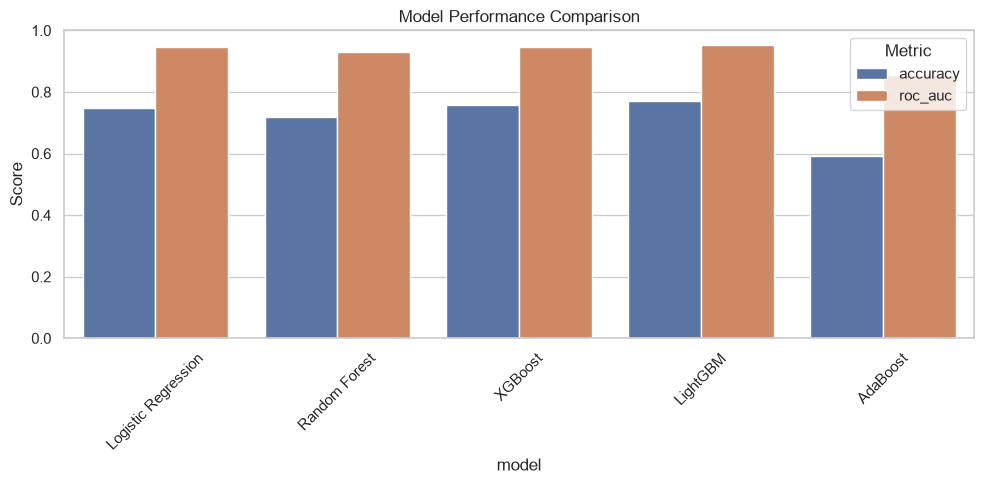

In [11]:
perf_df = pd.DataFrame([{
    "model": r["model"],
    "accuracy": r["accuracy"],
    "roc_auc": r["roc_auc"]
} for r in results])

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=perf_df.melt(id_vars="model"), x="model", y="value", hue="variable")
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Confusion Matrix for Best Model
Display the confusion matrix for the best-performing model by accuracy.

Best model: LightGBM


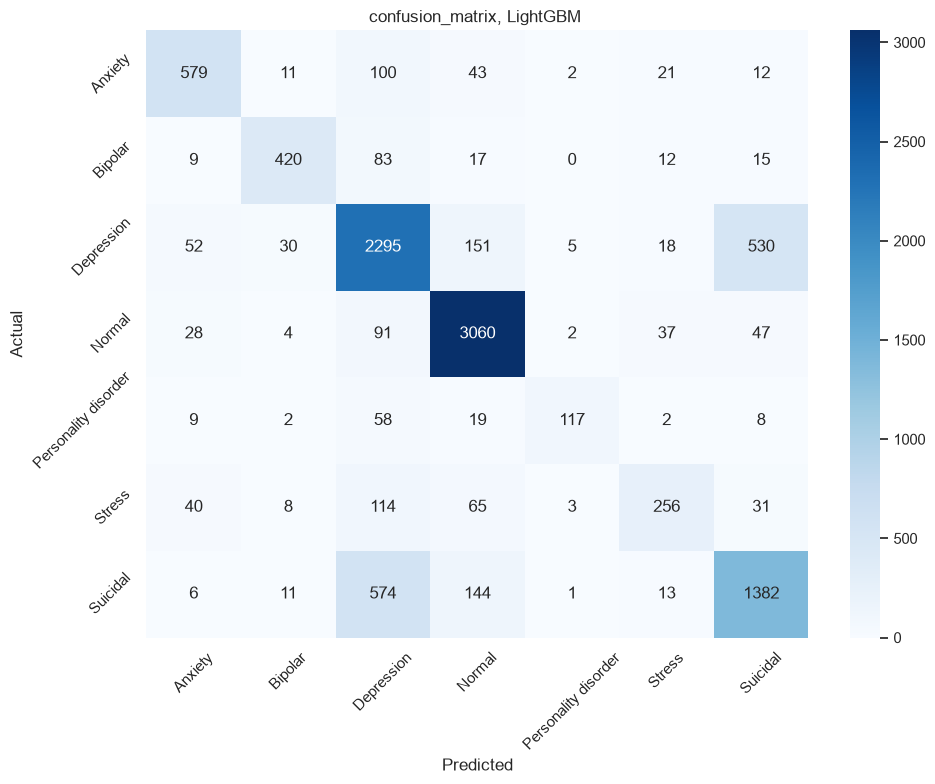

In [14]:
best = max(results, key=lambda item: item["accuracy"])
best_model = best["estimator"]
print("Best model:", best["model"])

plt.figure(figsize=(10, 8))
sns.heatmap(best["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'confusion_matrix, {best["model"]} ')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


## Cross-Validation for Robustness
Run 5-fold cross-validation on each model to estimate generalization performance.

Logistic Regression: CV accuracy = 0.7128 (+/- 0.0410)
Random Forest: CV accuracy = 0.6895 (+/- 0.0803)


/opt/homebrew/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:56:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:57:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:58:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:59:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

XGBoost: CV accuracy = 0.7220 (+/- 0.0610)


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: CV accuracy = 0.7320 (+/- 0.0592)
AdaBoost: CV accuracy = 0.5809 (+/- 0.0506)


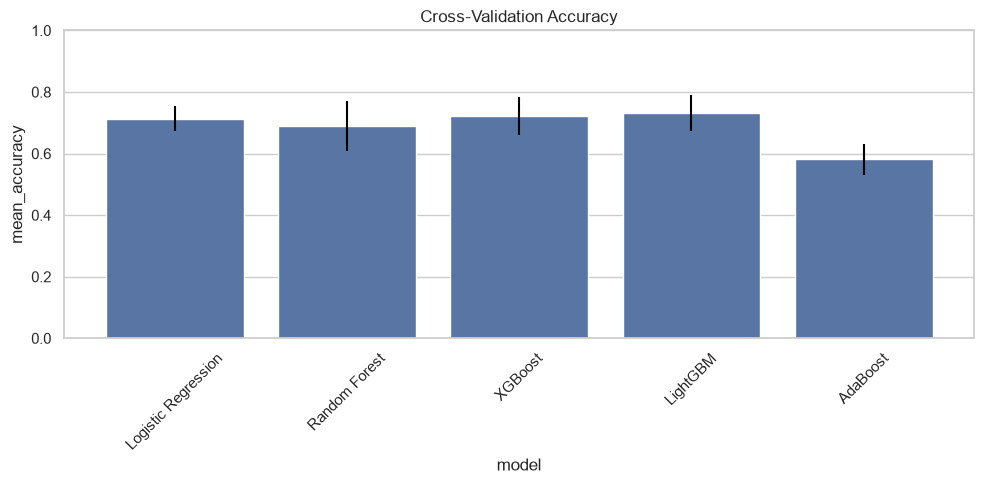

In [15]:
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y_encoded, cv=5, scoring="accuracy")
    cv_results.append({"model": name, "mean_accuracy": scores.mean(), "std_accuracy": scores.std()})
    print(f"{name}: CV accuracy = {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(10, 5))
sns.barplot(data=cv_df, x="model", y="mean_accuracy")
plt.errorbar(x=np.arange(len(cv_df)), y=cv_df["mean_accuracy"], yerr=cv_df["std_accuracy"]*2, fmt="none", c="black")
plt.title("Cross-Validation Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Save Best Model and Artifacts
Persist the best model, TF-IDF vectorizer, label encoder, and training summary.

In [ ]:
output_dir = os.path.join("artifacts", "mental_health_model")
os.makedirs(output_dir, exist_ok=True)

joblib.dump(vectorizer, os.path.join(output_dir, "tfidf_vectorizer.pkl"))
joblib.dump(label_encoder, os.path.join(output_dir, "label_encoder.pkl"))
joblib.dump(best_model, os.path.join(output_dir, "best_model.pkl"))

summary = pd.DataFrame([{
    "model": r["model"],
    "accuracy": r["accuracy"],
    "roc_auc": r["roc_auc"]
} for r in results])
summary.to_csv(os.path.join(output_dir, "model_summary.csv"), index=False)

print("Saved best model and artifacts to", output_dir)
